# 01 · Exploratory data analysis

Questions this notebook answers before modelling:

1. How rare are storm levels (Kp ≥ 5, 6, 7)? → class imbalance, calibration.
2. How does activity change over the solar cycle? → why the test split must cover Solar Cycle 25.
3. How fast does Kp "forget"? Is the 27-day recurrence visible? → persistence baseline, embargo gap, weeks-ahead hint.
4. Does solar-wind coupling actually track Kp? → feature design.
5. Where are the data gaps?

Data: `data/processed/` built by `scripts/build_dataset.py` (OMNI2 hourly + GFZ Kp).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from aurora.config import PROCESSED_DIR

plt.rcParams.update({"figure.figsize": (10, 3.5), "axes.grid": True, "grid.alpha": 0.3})

kp = pd.read_parquet(PROCESSED_DIR / "kp_3h.parquet")
hourly = pd.read_parquet(PROCESSED_DIR / "hourly.parquet")

# Modelling period: 1998-2025, definitive Kp only
kp = kp.loc["1998":"2025"]
kp = kp[kp.kp_definitive]
print(f"{len(kp):,} three-hour Kp intervals, {kp.index[0]:%Y-%m-%d} .. {kp.index[-1]:%Y-%m-%d}")

81,816 three-hour Kp intervals, 1998-01-01 .. 2025-12-31


## 1 · How rare are storms?

The model will predict these Kp classes. Exceedance probabilities are tail sums of the classes.

Class shares (%):
kp
≤3    88.30
4      7.63
5      2.73
6      0.88
7+     0.45

Exceedance (%):
Kp ≥ 4    11.70
Kp ≥ 5     4.06
Kp ≥ 6     1.33
Kp ≥ 7     0.45
Kp ≥ 8     0.16


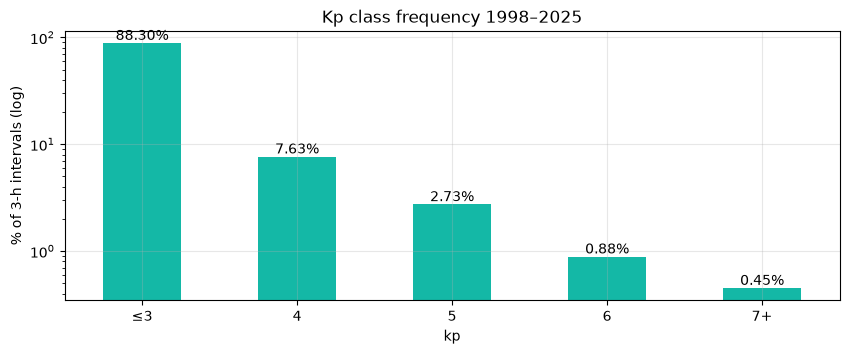

In [2]:
# A level k is reached from k- upwards (k - 1/3), matching NOAA's G-scale convention.
bins = [-0.1, 3.5, 4.5, 5.5, 6.5, 10]  # 3+ (3.33) -> "<=3", 4- (3.67) -> "4", ...
labels = ["≤3", "4", "5", "6", "7+"]
cls = pd.cut(kp.kp, bins=bins, labels=labels)
share = cls.value_counts(normalize=True).reindex(labels)

thresholds = pd.Series({f"Kp ≥ {k}": (kp.kp >= k - 0.34).mean() for k in (4, 5, 6, 7, 8)})
print("Class shares (%):")
print((share * 100).round(2).to_string())
print()
print("Exceedance (%):")
print((thresholds * 100).round(2).to_string())

ax = (share * 100).plot.bar(color="#14b8a6", rot=0)
ax.set_yscale("log")
ax.set_ylabel("% of 3-h intervals (log)")
ax.set_title("Kp class frequency 1998–2025")
for p, v in zip(ax.patches, share * 100):
    ax.annotate(f"{v:.2f}%", (p.get_x() + p.get_width() / 2, p.get_height()), ha="center", va="bottom")
plt.show()

**Takeaway:** quiet conditions dominate. Kp ≥ 7 occurs in well under 1 % of intervals, so plain accuracy is useless as a metric (always predicting "quiet" is >99 % accurate). We use Brier skill score, reliability diagrams and PR-AUC, and evaluate storm periods separately.

**Threshold convention:** a value is counted as reaching level k from k− upwards (for example 5− = 4.67 counts as Kp 5), which matches the class bins above. This choice has to be fixed before modelling and documented in the model card.

## 2 · Solar cycle dependence

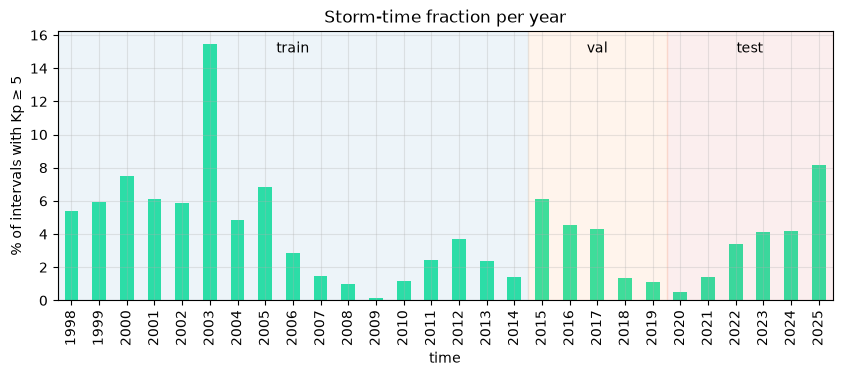

In [3]:
yearly = kp.kp.ge(5 - 0.34).groupby(kp.index.year).mean() * 100
ax = yearly.plot.bar(color="#2ee6a6", rot=90)
ax.set_ylabel("% of intervals with Kp ≥ 5")
ax.set_title("Storm-time fraction per year")
years = list(yearly.index)
for name, (a, b), c in [("train", (1998, 2014), "C0"), ("val", (2015, 2019), "C1"), ("test", (2020, 2025), "C3")]:
    i0, i1 = years.index(a), years.index(b)
    ax.axvspan(i0 - 0.5, i1 + 0.5, alpha=0.08, color=c)
    ax.text((i0 + i1) / 2, ax.get_ylim()[1] * 0.92, name, ha="center")
plt.show()

**Takeaway:** storm frequency varies by an order of magnitude across the ~11-year cycle. The test period (2020–2025) covers the rise and maximum of Cycle 25, so it is a demanding, realistic test. The validation period (2015–2019) is the declining phase and minimum of Cycle 24, which is quieter. Keep this in mind when comparing validation and test scores.

## 3 · Persistence and the 27-day recurrence

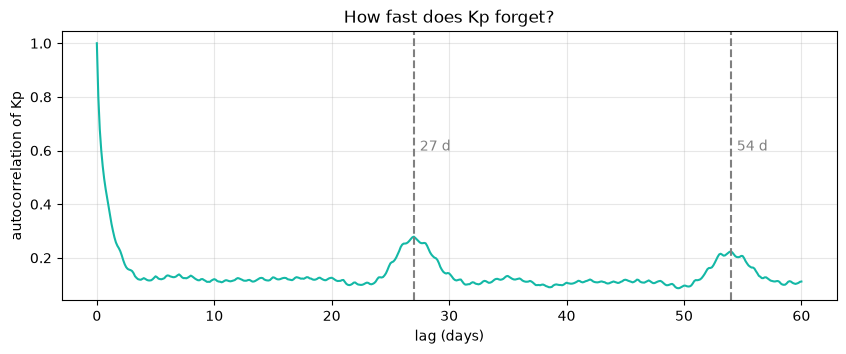

lag   3 h: r = 0.80
lag   6 h: r = 0.68
lag  12 h: r = 0.54
lag  24 h: r = 0.39
lag  72 h: r = 0.15
lag  20 d: r = 0.13
lag  27 d: r = 0.28
lag  34 d: r = 0.12
lag  54 d: r = 0.22


In [4]:
s = kp.kp.asfreq("3h")
lags = np.arange(0, 60 * 8 + 1)  # in 3-hour steps, up to 60 days
acf = np.array([s.autocorr(lag=int(l)) for l in lags])

fig, ax = plt.subplots()
ax.plot(lags / 8, acf, color="#14b8a6")
for d in (27, 54):
    ax.axvline(d, ls="--", color="grey")
    ax.text(d + 0.5, 0.6, f"{d} d", color="grey")
ax.set_xlabel("lag (days)")
ax.set_ylabel("autocorrelation of Kp")
ax.set_title("How fast does Kp forget?")
plt.show()

for h in (3, 6, 12, 24, 72):
    print(f"lag {h:>3} h: r = {s.autocorr(lag=h // 3):.2f}")
for d in (20, 27, 34, 54):
    print(f"lag {d:>3} d: r = {s.autocorr(lag=d * 8):.2f}")

**Takeaways:**
- Kp is strongly autocorrelated over a few hours, so **persistence is a strong baseline** at 1–3 h. Our model has to beat it.
- The correlation drops within about a day, which is why a few-hours model can't make a 3-night outlook.
- There are clear peaks at **27 and 54 days** (compare with the 20- and 34-day lags): coronal holes returning with the Sun's rotation. They are real but weak, which justifies a *low-confidence* weeks-ahead hint and nothing stronger.
- This autocorrelation is also why the train/val/test splits need an **embargo gap** of about 30 days.

## 4 · Does solar-wind coupling track Kp?

Newell coupling `dΦ/dt = V^(4/3) · Bt^(2/3) · sin^(8/3)(θ/2)` estimates the rate of dayside reconnection, i.e. how much solar-wind energy enters the magnetosphere.

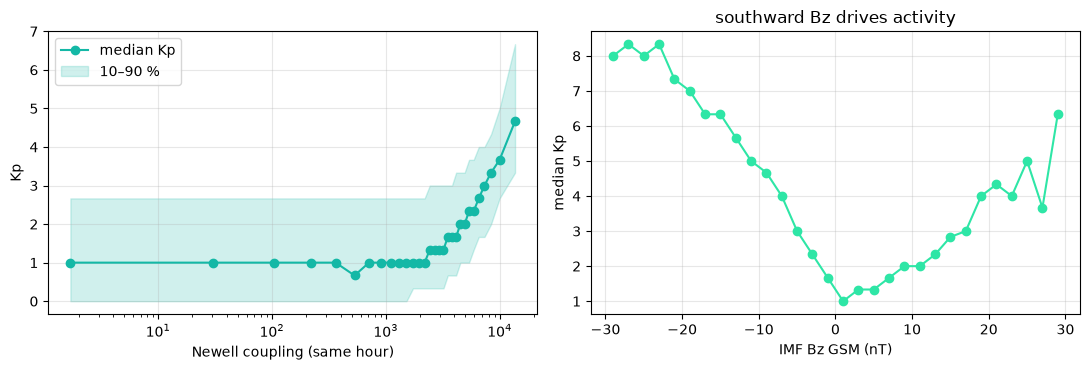

Spearman (rank) correlation with Kp:
newell    0.55
bz       -0.33


In [5]:
bt = np.hypot(hourly.by_gsm, hourly.bz_gsm)
theta = np.arctan2(hourly.by_gsm, hourly.bz_gsm)  # clock angle: 0 = northward, pi = southward
newell = hourly.speed ** (4 / 3) * bt ** (2 / 3) * np.abs(np.sin(theta / 2)) ** (8 / 3)
df = pd.DataFrame({"newell": newell, "bz": hourly.bz_gsm, "kp": hourly.kp_bin}).dropna().loc[:"2025"]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
q = pd.qcut(df.newell, 30)
g = df.groupby(q, observed=True).kp
mid = df.groupby(q, observed=True).newell.median()
axes[0].plot(mid, g.median(), "o-", color="#14b8a6", label="median Kp")
axes[0].fill_between(mid, g.quantile(0.1), g.quantile(0.9), alpha=0.2, color="#14b8a6", label="10–90 %")
axes[0].set_xscale("log")
axes[0].set_xlabel("Newell coupling (same hour)")
axes[0].set_ylabel("Kp")
axes[0].legend()

b = pd.cut(df.bz, np.arange(-30, 31, 2))
gb = df.groupby(b, observed=True).kp.median()
axes[1].plot([i.mid for i in gb.index], gb, "o-", color="#2ee6a6")
axes[1].set_xlabel("IMF Bz GSM (nT)")
axes[1].set_ylabel("median Kp")
axes[1].set_title("southward Bz drives activity")
plt.tight_layout()
plt.show()

print("Spearman (rank) correlation with Kp:")
print(df[["newell", "bz"]].rank().corrwith(df.kp.rank()).round(2).to_string())

**Takeaways:**
- Kp rises steadily with Newell coupling, and **southward Bz (negative) drives activity** while northward Bz barely does. This confirms the physics behind the feature set.
- The 10–90 % band is wide: the same hourly coupling can give quite different Kp. Two reasons are that the magnetosphere *integrates* its input over hours (hence the rolling-window features) and that Kp is a 3-hour index. This spread is the reason for predicting probabilities instead of a single number.

## 5 · Data gaps

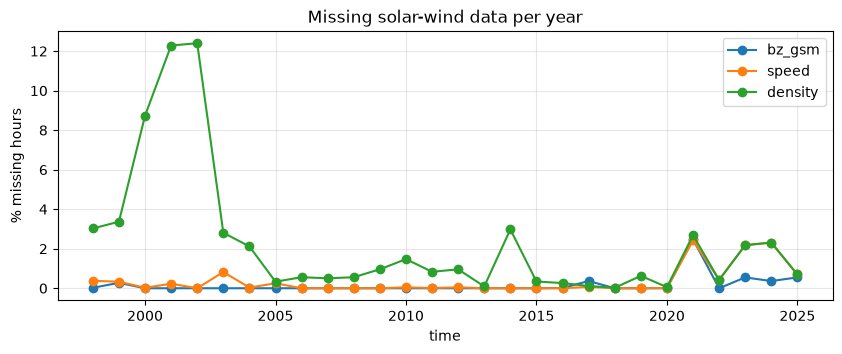

time     1998  1999  2000  2001  2002  2003  2004  2005  2006  2007  2008  2009  2010  2011  2012  2013  2014  2015  2016  2017  2018  2019  2020  2021  2022  2023  2024  2025
bz_gsm    0.0   0.3   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.4   0.0   0.0   0.0   2.5   0.0   0.5   0.4   0.5
speed     0.4   0.3   0.0   0.2   0.0   0.8   0.0   0.3   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.1   0.0   0.0   0.0   2.4   0.4   2.2   2.3   0.7
density   3.0   3.4   8.7  12.3  12.4   2.8   2.1   0.3   0.6   0.5   0.6   1.0   1.5   0.8   1.0   0.1   3.0   0.3   0.3   0.1   0.0   0.6   0.1   2.7   0.4   2.2   2.3   0.7


In [6]:
h = hourly.loc[:"2025"]
gaps = h[["bz_gsm", "speed", "density"]].isna().groupby(h.index.year).mean() * 100
ax = gaps.plot(marker="o")
ax.set_ylabel("% missing hours")
ax.set_title("Missing solar-wind data per year")
plt.show()
print(gaps.round(1).T.to_string())

**Takeaway:** gaps are small overall, but plasma (density/speed) is missing more often than the magnetic field. LightGBM handles NaN natively, so no imputation is needed. The same will apply to live DSCOVR/ACE outages in production.

## Summary for modelling
| Finding | Decision |
|---|---|
| Kp ≥ 7 < 1 % of intervals | probabilistic output, Brier/BSS + PR-AUC, separate storm evaluation |
| Strong cycle dependence | test on 2020–2025 (Cycle 25), report per-period scores |
| High short-lag autocorrelation | persistence baseline; ~30-day embargo between splits |
| 27/54-day peaks | weeks-ahead hint from recurrence, shown as low confidence |
| Kp tracks Newell coupling and southward Bz | coupling + rolling windows as core features |
| Small, plasma-heavy gaps | no imputation; rely on LightGBM NaN handling |